# 2장 5강 A/B 테스트 핵심 메커니즘과 실험 설계 오류 식별

## Intro

**과제 소개**
프로모션 A/B 데이터를 확인하고, 실험 결과를 신뢰하려면 어떤 조건을 점검해야 하는지 설명합니다. 교안의 개념을 이용해 **판단 → 사례 속 근거 → 이유 → 수정 방향**을 연결하는 것이 목표입니다.

**과제 목표**
- 대조군·실험군과 무작위 배정의 역할을 설명한다.
- 분석 단위·기간·핵심 지표·표본 크기를 구분한다.
- 신규성 효과·표본 오염·조기 종료·SRM을 사례의 근거로 진단한다.
- 핵심 지표와 중요한 보조 지표, 실험 조건을 함께 검토해 결론을 작성한다.

**구성**: 필수 1(중급 초입) → 필수 2(중급) → 과제 1(중급). **필수 1·2는 제출·채점 대상이 아니며, 과제 1만 제출·채점 대상**입니다.

**사용 툴/라이브러리**: Python, Jupyter Notebook, pandas, NumPy, matplotlib.

**학습 범위**: 판단에 필요한 개념은 교안의 1~4절을 사용합니다. 기본 pandas 집계·필터링은 기존 학습 내용을 활용하며, 새로운 통계 검정·표본 크기 계산·세그먼트 분석·수익 지표 설계는 요구하지 않습니다. 데이터 로딩과 그래프 코드는 제공합니다.

### 사용 데이터와 주요 컬럼

| 컬럼 | 의미 | 이번 실습에서의 사용 |
|---|---|---|
| LocationID | 매장 식별자 | 매장 수와 매장별 평균 계산 |
| Promotion | 프로모션 구분 | 1=A, 2=B로 가정; 3은 비교에서 제외 |
| week | 관측 주차 | 주차별 비교 |
| SalesInThousands | 천 단위로 기록된 매출 | 핵심 지표 계산 |
| MarketID / MarketSize / AgeOfStore | 시장·매장 특성 | 이번 실습에서는 분석하지 않음 |

### 분석에 필요한 설명 — 새로운 개념을 추론할 필요가 없도록 제공
- 실제 데이터는 `WA_Marketing-Campaign.csv`입니다. 같은 매장이 4주 동안 반복 기록되어 있습니다.
- 이 실습에서는 **매장을 배정·분석 단위**로 정합니다. 한 매장의 주차별 행이 여러 개여도 서로 다른 매장 여러 곳으로 세지 않습니다.
- 핵심 지표는 **매장별 4주 평균 주간 매출을 계산한 뒤, 그 값을 집단별로 평균한 값**입니다. 4주 누적 매출이 아닙니다.
- A는 기존 프로모션, B는 변경 프로모션이라는 **수업용 역할 가정**입니다. CSV가 실제 기존안·변경안을 알려주는 것은 아닙니다.
- 실제 배정 절차·예정 기간·목표 표본 수·예정 배정 비율은 CSV에 없습니다. 따라서 실제 데이터 문제와 별도로 **교육용 사례**의 조건을 명시합니다. 교육용 수치를 실제 WA 관측 결과와 섞지 않습니다.
- 무작위 배정은 각 대상이 정해진 확률로 배정되게 하는 절차입니다. 결과적인 집단 수가 반드시 같아야 한다는 뜻은 아닙니다.

### 파일 및 제출 안내
- 함께 제공된 실습문제·정답 및 해설 노트북과 기존 `WA_Marketing-Campaign.csv`를 사용합니다.
- 제출 방식: 개인 GitHub 저장소 링크. 예: `product-analysis-assignment-이름/ch03/lesson01.ipynb`, `data/WA_Marketing-Campaign.csv`.
- 제출 노트북에 준비 코드, 과제 1의 코드·실행 결과·요구사항별 답안·Q&A를 포함합니다. 필수 실습 결과를 재사용한다면 필요한 코드도 포함합니다.
- 두 파일 모두 **같은 요구사항 번호**로 구분합니다. 정답 파일의 각 번호에서 코드와 해설을 함께 확인할 수 있습니다.

**파일 구분: 실습문제**

## 실습 준비 — 제공 코드
`DATA_PATH`에 직접 CSV 경로를 입력하거나 `None`을 유지하고 노트북 폴더·`data`·`upload`·`/content`에 CSV를 둡니다. 여러 후보가 발견되면 사용할 파일의 경로를 직접 지정합니다.
아래 코드는 A/B 데이터를 준비하고, 과제에서 사용할 매장별 평균 테이블도 만들어 줍니다. 원본의 Promotion을 새 라벨로 바꾸지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
# 직접 지정하는 예: DATA_PATH = r"C:\Users\사용자명\Downloads\WA_Marketing-Campaign.csv"
DATA_PATH = None
if DATA_PATH is not None:
    csv_path = Path(DATA_PATH).expanduser()
else:
    folders = [Path("."), Path("data"), Path("upload"), Path("/content"), Path("../data")]
    found = list(dict.fromkeys((p / "WA_Marketing-Campaign.csv").resolve()
                              for p in folders if (p / "WA_Marketing-Campaign.csv").is_file()))
    if len(found) != 1:
        raise FileNotFoundError(f"CSV 후보 {len(found)}개. DATA_PATH를 지정하세요. 후보: {found}")
    csv_path = found[0]
campaign = pd.read_csv(csv_path)
campaign_ab = campaign[campaign["Promotion"].isin([1, 2])].copy()
# 같은 매장의 4주 매출을 평균하여 한 매장을 한 행으로 정리합니다.
location_sales = (
    campaign_ab.groupby(["LocationID", "Promotion"], as_index=False)["SalesInThousands"]
    .mean().rename(columns={"SalesInThousands": "four_week_mean_sales"})
)
print("전체 데이터 크기:", campaign.shape)
print("A/B 데이터 크기:", campaign_ab.shape)
display(campaign_ab.head())
display(location_sales.head())

전체 데이터 크기: (548, 7)
A/B 데이터 크기: (360, 7)


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
4,1,Medium,2,5,2,1,27.81
5,1,Medium,2,5,2,2,34.67
6,1,Medium,2,5,2,3,27.98
7,1,Medium,2,5,2,4,27.72
8,1,Medium,3,12,1,1,44.54


,LocationID,Promotion,four_week_mean_sales
0,2,2,29.5450
1,3,1,40.6800
2,4,2,33.7075
3,5,2,29.0025
4,7,1,43.2425


---
## 필수 1. 데이터에서 설계 4대 요소를 구분하기

<aside>
담당자가 “데이터 행 수가 많으니 표본이 충분하고, 두 집단의 수가 비슷하니 무작위 배정도 확인됐다”고 말했습니다. 데이터로 확인되는 사실과 계획서를 봐야 하는 사항을 구분하세요.
이 실습은 제출·채점 대상이 아닙니다.
</aside>

### 문제 1-1. 분석 단위와 무작위 배정 이해

**요구사항**
1. A/B 각각의 행 수와 고유 매장 수, 전체 관측 주차를 출력하세요. 대조군·실험군을 적고, 행 수와 매장 수 중 어느 것을 이번 실습의 표본 수로 사용할지 설명하세요.
2. 설계 4대 요소를 표로 정리하세요. 각 요소에 대해 **이번 분석의 정의 또는 관측값 / CSV만으로 확인하지 못한 사전 계획**을 적으세요.  
관측된 4주를 사전에 계획한 4주로 단정하지 않습니다.
3. **다음 실험을 위한 배정 연습**으로 가상의 매장 100개를 A/B에 각각 0.5 확률로 배정하세요.  
교안의 `np.random.seed(42)`, `np.random.choice()`를 사용하고 집단별 매장 수를 출력하세요.  
정확히 50:50이어야 하는지 설명하세요. 실제 WA 매출에는 이 모의 라벨을 붙이지 않습니다.
4. 아래 Q1·Q2에 답하세요.

**확인 포인트 — 요구사항과 1:1 대응**
1. A/B 역할·행 수·매장 수·관측 주차가 정확하며 매장을 표본 단위로 설명했는가?
2. 네 요소 모두를 작성하고 관측 결과와 사전 계획을 구분했는가?
3. 정해진 확률로 한 번씩 배정하고 결과적인 인원수와 무작위 배정을 구분했는가?
4. Q1·Q2에서 교안의 무작위 배정과 사전 표본 크기 결정 원리를 적용했는가?

**Q&A**
- Q1. 집단별 매장 수가 비슷하면 실제 무작위 배정이 이루어졌다고 말할 수 있나요?  
- Q2. 현재 관측된 매장 수만 보고 실험에 필요한 표본 수를 충분히 확보했다고 말할 수 있나요?  

### 필수 1 · 요구사항 1 — 역할·표본 수·기간 확인

In [5]:
for promo, label in [(1, "A (기존 프로모션, 대조군)"), (2, "B (변경 프로모션, 실험군)")]:
    sub = campaign_ab[campaign_ab["Promotion"] == promo]
    print(f"{label}")
    print(f"  행 수: {sub.shape[0]}")
    print(f"  고유 매장 수: {sub['LocationID'].nunique()}")
    print(f"  관측 주차: {sorted(sub['week'].unique())}")

A (기존 프로모션, 대조군)
  행 수: 172
  고유 매장 수: 43
  관측 주차: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
B (변경 프로모션, 실험군)
  행 수: 188
  고유 매장 수: 47
  관측 주차: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


**답안 작성**

- 계산·출력 결과:  
A (기존 프로모션, 대조군): 행 수 172, 고유 매장 수 43, 관측 주차 [1, 2, 3, 4]  
B (변경 프로모션, 실험군): 행 수 188, 고유 매장 수 47, 관측 주차 [1, 2, 3, 4]  

- 결과 해석 또는 판단 근거: 매장을 분석 단위로 정했기 때문에, 표본 수는 행 수(172, 188)가 아닌 고유 매장 수(43, 47)를 사용해야함  
행 수를 그대로 표본 수로 사용하면 실제 표본 크기(43개, 47개 매장)보다   
4배 부풀려진 값(172개, 188개)을 쓰게 되어 잘못된 판단으로 이어질 수 있음

### 필수 1 · 요구사항 2 — 설계 4대 요소 표
| 요소 | 이번 분석의 정의 또는 관측값 | CSV만으로 확인하지 못한 사전 계획 |
|---|---|---|
| 분석 단위 | 문제에서 매장으로 정의 | 실제 배정에서도 매장을 기준으로 나누었는지 |
| 실험 기간 | 1~4주 관측 | 원래 몇 주 하기로 했는지, 언제 종료했는지 |
| 핵심 지표 | 매장별 4주 평균 주간 매출의 집단 평균 | 실험 전에 이 지표를 성공 판단 기준으로 정했는지 |
| 표본 크기 | A 43개, B 47개 매장 | 원래 확보할 목표 매장 수가 얼마였는지 |

**답안 작성**

- 판단 및 근거: 매출 집단 평균으로 봄 / 집단 별로 매출 평균을 보고싶었기 때문에 매출 집단을 KPI로 봄
- 수정 방향 또는 추가 확인 사항: 데이터 전처리 파트 확인, 추가적인 데이터가 있는지 확인

### 필수 1 · 요구사항 3 — 교안 방식으로 무작위 배정 연습

In [4]:
np.random.seed(42)
practice_stores = np.arange(1, 101)
# np.random.choice()로 A/B에 0.5씩 배정하고 각각의 개수를 출력하세요.

mock_assignment = np.random.choice(["A", "B"], size=100, p=[0.5, 0.5])
mock_counts = pd.Series(mock_assignment).value_counts()
print(mock_counts)

A    53
B    47
Name: count, dtype: int64


**답안 작성**

- 계산·출력 결과: A: 53, B: 47
- 결과 해석 또는 판단 근거: 각 매장을 0.5 확률로 배정했음에도, 결과는 53:47로 나옴.  
무작위 배정은 "각 대상이 정해진 확률로 배정되는 절차"를 의미하며 "결과적인 두 집단의 **수**가 똑같아야 한다"는 뜻은 X.  
표본이 많을수록 50:50에 가까워질 가능성은 높아지겠지만, 정확히 같아야만 무작위 배정이 성립하는 것은 아님.

### 필수 1 · 요구사항 4 — Q&A

**답안 작성**
- Q1. 집단별 매장 수가 비슷하면 실제 무작위 배정이 이루어졌다고 말할 수 있나요?  
-> `아닐 수 있음, 예를 들어 매출이 높은 매장을 A에, 낮은 매장을 B에 배치하면서 양쪽 숫자를 비슷하게 가져갈 수도 있음`  
-> `실제 배정 방식과 기록을 확인해야함`  

- Q2. 현재 관측된 매장 수만 보고 실험에 필요한 표본 수를 충분히 확보했다고 말할 수 있나요?  
-> `아닐 수 있음, 현재에는 관측 수만 있고 목표한 수치가 없으므로 충분성을 확인할 수 없음`

---
## 필수 2. 교안의 네 오류를 근거와 수정 방향으로 설명하기

<aside>
오류 이름만 맞히는 데서 끝내지 않습니다. 실제 주차별 매출을 읽고, 조건이 명시된 교육용 사례에서 판단 근거와 수정 방향을 제시하세요.
이 실습은 제출·채점 대상이 아닙니다.
</aside>

### 문제 2-1. 오류 식별과 결과 해석

**요구사항**
1. 제공 코드를 실행해 실제 WA 데이터의 주차별 A/B 평균 매출을 확인하고 `B−A`를 계산하세요. 1주차·4주차 차이를 제시하고, 이 추이만으로 신규성 효과를 확정할 수 있는지 설명하세요.  
**읽는 방법**: `B−A`가 음수면 그 주의 B 평균이 A보다 낮습니다. 신규성 효과는 새로운 경험에 대한 초기 반응이 시간이 지나며 약해지는 현상이며, 단순한 A/B 우열과 다릅니다.
2. 아래 교육용 사례 N·C·E·S 각각에 대해 **오류 또는 의심 오류 / 사례 속 근거 / 결과 해석에 생기는 문제 / 수정·확인 방향**을 표로 작성하세요.  
사례 N·S는 가능성 또는 의심 신호로 표현해도 됩니다. SRM의 통계 계산은 요구하지 않습니다.
3. 실제 WA 데이터에 관해 네 오류 각각을 **확인한 사실 / 추가로 필요한 정보** 표로 정리하세요.  
제공된 교차 배정 점검 코드를 실행합니다.  
코드가 확인하는 것은 CSV의 Promotion 기록뿐입니다. 교육용 사례를 실제 발생 사실로 쓰지 않습니다.  
4. 아래 Q1·Q2에 답하세요.

### 교육용 사례 — 실제 WA 기록이 아닌 별도 상황

| 사례 | 판단을 위해 제공하는 조건 |
|---|---|
| N | 새 프로모션에 대한 반응을 관찰했다. A의 주차별 평균은 50, 50, 50, 50이고 B는 60, 55, 51, 50이었다. 담당자는 첫 주만 근거로 장기 개선 효과가 확정되었다고 말했다. |
| C | 한 매장을 고정 배정하지 않고 매주 다시 배정했다. 같은 매장이 1주차에는 A, 2주차에는 B를 실제 적용받았다. 담당자는 두 집단이 서로 다른 프로모션만 경험했다고 보고했다. |
| E | 시작 전에 4주간 관측하기로 했다. 담당자는 1주차에 B의 평균이 높게 나오자 그 결과를 이유로 종료하고 출시하려 한다. |
| S | 별도 온라인 실험에서 사용자별 A/B 배정 확률을 0.5씩 정했다. 실제 수집 데이터에는 서로 다른 사용자 A 6,500명, B 3,500명이 있었다. 담당자는 배정·수집 상태를 확인하지 않고 매출만 비교하려 한다. |

**확인 포인트 — 요구사항과 1:1 대응**
1. 주차별 차이 계산과 부호 해석이 맞으며 신규성 효과를 확정하지 않았는가?
2. 네 사례 모두에 오류·근거·문제·수정 방향을 연결했는가?
3. 실제 관측과 교육용 조건을 분리하고, 오류별로 필요한 추가 정보를 적었는가?
4. Q1·Q2에서 사전 종료 기준과 표본 오염의 의미를 적용했는가?

**Q&A**
- Q1. 실제 데이터에서 1주와 4주 모두 A의 평균이 높다면, 1주차에 종료했어도 설계상 문제가 없다고 말할 수 있나요?
- Q2. CSV에서 매장별 Promotion 종류 수가 하나이면 모든 표본 오염이 없었다고 말할 수 있나요?

### 필수 2 준비 — 집계·그래프·기록 점검 제공 코드
집계와 그래프 작성 방법 자체는 평가하지 않습니다. 표의 `1`은 A, `2`는 B입니다. 아래 코드로 각 주차의 평균과 기록상 교차 배정 매장 수를 확인하세요.

Promotion,1,2
week,,
1,58.244,47.730
2,56.930,47.583
3,58.775,47.722
4,58.447,46.283


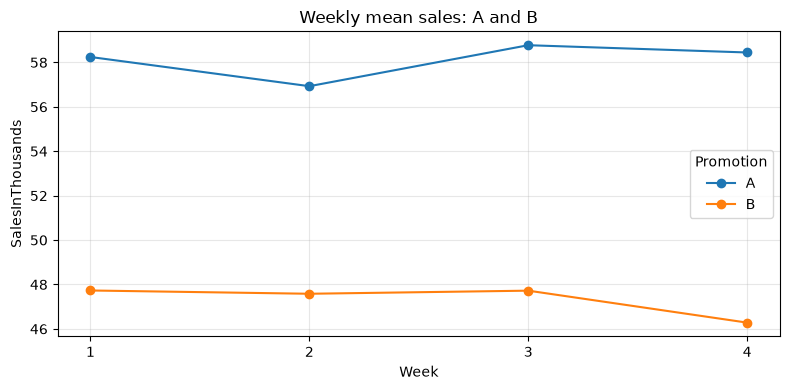

기록상 여러 Promotion이 있는 매장 수: 0


In [5]:
weekly_sales = (campaign_ab.groupby(["week", "Promotion"])["SalesInThousands"]
                .mean().unstack("Promotion").sort_index())
# unstack은 Promotion 1·2를 각각 열로 옮겨 두 집단을 나란히 읽게 합니다.
display(weekly_sales.round(3))
weekly_sales.rename(columns={1: "A", 2: "B"}).plot(marker="o", figsize=(8, 4))
plt.title("Weekly mean sales: A and B")
plt.xlabel("Week")
plt.ylabel("SalesInThousands")
plt.xticks([1, 2, 3, 4])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# 원본 전체를 점검하여 Promotion 3으로 바뀐 기록도 놓치지 않습니다.
promotion_kinds = campaign.groupby("LocationID")["Promotion"].nunique()
print("기록상 여러 Promotion이 있는 매장 수:", int((promotion_kinds > 1).sum()))

### 필수 2 · 요구사항 1 — 실제 주차별 차이 해석

In [7]:
# weekly_sales의 2열(B)에서 1열(A)을 빼서 B_minus_A 열을 만드세요.
# 표를 출력한 뒤 1주차와 4주차의 차이를 해석하세요.

weekly_sales = campaign_ab.groupby(["week", "Promotion"])["SalesInThousands"].mean().unstack("Promotion")
weekly_sales.columns = ["A_mean", "B_mean"]  # Promotion 1=A, 2=B로 가정 — 실제 라벨은 계획서 확인 필요
weekly_sales["B_minus_A"] = weekly_sales["B_mean"] - weekly_sales["A_mean"]
print(weekly_sales.round(2))

print("1주차 B-A:", round(weekly_sales.loc[1, "B_minus_A"], 2))
print("4주차 B-A:", round(weekly_sales.loc[4, "B_minus_A"], 2))

      A_mean  B_mean  B_minus_A
week                           
1      58.24   47.73     -10.51
2      56.93   47.58      -9.35
3      58.77   47.72     -11.05
4      58.45   46.28     -12.16
1주차 B-A: -10.51
4주차 B-A: -12.16


**답안 작성**
| 사례 | 오류 또는 의심 오류 | 사례 속 근거 | 결과 해석에 생기는 문제 | 수정·확인 방향 |
|---|---|---|---|---|
| N | 신규성 효과 가능성 | B-A가 10 → 5 → 1 → 0으로 줄어듦 | 첫 주의 높은 반응을 오래 유지되는 효과로 오해할 수 있음 | 전체 기간의 추이 확인, 초기 반응의 지속성을 검토. 첫 주만으로 장기 효과 확정 금지 |
| C | 표본 오염 | 같은 매장이 A와 B를 모두 실제 경험 | 두 집단이 서로 다른 처치만 경험한 비교라고 보기 어려움 | 매장별로 한 번 배정하고 실험 중 유지. 실제 적용 기록도 확인 |
| E | 조기 종료 | 4주 계획을 1주 결과가 좋다는 이유로 중단 | 우연히 좋은 시점의 결과를 선택하여 개선 효과 과신할 수 있음 | 사전에 정한 기간·종료 기준을 지키고 전체 계획에 따라 판단 |
| S | SRM 의심 | 예정 50:50 대비 수집 65:35 | 특정 집단의 누락 또는 배정 문제로 비교가 왜곡되었을 수 있음 | 배정 로직과 수집 누락부터 확인한 뒤 결과 판단 재개 |

- 계산·출력 결과:
- 결과 해석 또는 판단 근거:

### 필수 2 · 요구사항 2 — 교육용 사례 진단표

**답안 작성**

- 판단 및 근거:
- 수정 방향 또는 추가 확인 사항:

### 필수 2 · 요구사항 3 — 실제 데이터의 확인 범위

**답안 작성**

- 판단 및 근거:
- 수정 방향 또는 추가 확인 사항:

### 필수 2 · 요구사항 4 — Q&A

**답안 작성**
- Q1. 실제 데이터에서 1주와 4주 모두 A의 평균이 높다면, 1주차에 종료했어도 설계상 문제가 없다고 말할 수 있나요?  
-> `아니오 나중에 전체 결과의 방향이 같았다고 해서 중간 결과를 보고 임의로 끝내는 방식이 정당해지지는 않습니다.  
종료 기준은 결과를 보기 전에 정해야합니다.   
실제 WA 실험의 조기 종료 여부는 원래 계획과 종료 이유가 있어야 판단할 수 있음. 반면 교육용 E에는 4주 계획과 성과에 따른 1주 종료가 명시되어있습니다.`  
- Q2. CSV에서 매장별 Promotion 종류 수가 하나이면 모든 표본 오염이 없었다고 말할 수 있나요?  
-> `아니오. 기록상 한 종류라는 사실만 확인한 것입니다. 기록에는 A로 남아있어도 실제 현장에서 B프로모션을 함께 적용했을 가능성까지 이 파일이 확인해주지는 않습니다.  
실제 적용 기록도 확인해야합니다.`

핵심 정리 : 일부 점검 결과를 실험 전체의 정상 판정으로 확대하지 않습니다.


---
## 과제 1. 교안 개념으로 보고서를 고치고 적용 여부 판단하기

<aside>
A를 기존안, B를 변경안으로 가정합니다. 실제 매출을 비교하고 잘못된 보고서를 고친 뒤, 교안의 실험 설계 요소와 결과 해석 원칙으로 다음 행동을 제시하세요.
과제 1(문제 3-1)만 제출·채점 대상입니다.
</aside>

### 문제 3-1. 프로모션 분석 검토 보고서

**잘못된 보고서 초안 — 수정 대상**
1. “A 172개·B 188개 매장을 확보했으므로 필요한 표본 수를 충족했다.”
2. “두 집단의 매장 수가 비슷하므로 무작위 배정이 정상적으로 이루어졌음이 증명되었다.”
3. “1주차에 A가 높았고 4주에도 같으니 1주차 결과만 보고 종료해도 문제가 없다.”
4. “B가 모든 주에서 A보다 낮으므로 신규성 효과는 없다고 확인했다.”
5. “현재 평균에서 B가 낮으므로 다른 조건을 확인할 필요 없이 B는 앞으로도 영구 폐기한다.”

**요구사항**
1. 제공된 `location_sales`로 집단별 평균을 계산하고 `B−A`를 출력하세요. A/B 값·차이·단위를 제시하여 관측 성과를 해석하세요. 이번 강의에서는 유의성 검정이나 인과 효과 확정을 요구하지 않습니다.
2. 초안 1~5번을 각각 **수정 문장 / 실제 수치 또는 교안 근거**로 고치세요. 오류 지적만 하지 말고 보고서에 사용할 수 있는 문장으로 작성합니다.
3. 아래 **교육용 후속 실험 결과**를 보고 B를 바로 전면 적용할지 판단하세요. 핵심 지표 변화·보조 지표 변화·추가 확인을 포함합니다. 주어진 값을 읽어 판단하면 되며 지표 계산식 설계는 요구하지 않습니다.
4. 다음에 실시할 실험의 설계 4대 요소를 표로 작성하세요. 아래 **제공된 계획 조건**을 사용하고 각 요소의 이유를 한 줄씩 설명합니다. 무작위 배정 고정 방식과 중간 결과가 좋을 때의 처리도 덧붙입니다.
5. **실제 WA 결과**에 대한 최종 권고를 4~6문장으로 작성하세요. B 전환 여부·수치 근거·확인하지 못한 실험 조건·다음 확인 행동을 포함하고 Q1·Q2에 답하세요. 요구사항 3의 교육용 수치를 실제 WA 결과에 섞지 않습니다.

### 요구사항 3: 교육용 후속 실험 — WA 실제 결과 아님

| 항목 | A | B |
|---|---:|---:|
| 핵심 지표: 매장별 평균 주간 매출(천 단위) | 50 | 55 |
| 중요한 보조 지표: 환불률 | 2% | 5% |

이 후속 실험은 계획된 기간과 표본 수를 충족했고, 매출 차이는 통계적으로 유의하다는 결과가 제공되었다고 가정합니다. 직접 검정하지 않습니다. 환불률 악화를 어느 정도까지 허용할지는 아직 검토되지 않았고, 배정·수집·실제 적용 점검 결과는 제공되지 않았습니다.

### 요구사항 4: 다음 실험의 제공된 계획 조건 — 새 계획용 가정
- 기존 A와 변경 B의 매출을 비교한다.
- 매장을 기준으로 각각 A/B에 0.5 확률로 한 번 배정하고, 같은 매장은 실험 내내 같은 프로모션을 사용한다.
- 모든 참여 매장이 같은 시점부터 4주간 관측되도록 시작 전에 일정을 확정한다.
- 핵심 지표는 매장별 4주 평균 주간 매출의 집단 평균이다.

- **목표 표본 크기는 실험 전에 별도 담당자가 산정하여 확정한 전체 100개 매장으로 주어진다.** 산정 방법은 이번 강의 범위가 아니며, 100개를 학생이 계산하거나 충분성을 증명할 필요는 없다.
- 계획한 100개 매장을 확보하고 각 매장의 4주 관측을 완료한다. 중간 매출이 좋아 보인다는 이유로 임의 종료하지 않는다.

**확인 포인트 — 요구사항과 1:1 대응**
1. 제공된 매장 단위 평균을 집단별로 비교하고 단위·관측 차이를 정확히 설명했는가?
2. 초안 다섯 문장을 모두 실제 근거와 교안 원리에 맞게 수정했는가?
3. 교육용 핵심·보조 지표를 함께 읽고 실험 조건까지 확인하도록 제안했는가?
4. 제공 조건으로 설계 4대 요소와 이유를 쓰고 배정·종료 원칙을 유지했는가?
5. 실제 WA 근거만으로 권고를 작성하고 Q1·Q2에 답했는가?

**Q&A**
- Q1. 교육용 후속 실험에서 매출 차이가 통계적으로 유의하다고 주어졌는데도 다른 조건을 확인해야 하는 이유는 무엇인가요?
- Q2. 다음 실험에서 전체 100개 매장을 0.5 확률로 배정했는데 53:47로 나뉘었다면, 정확히 50:50으로 맞추기 위해 배정된 매장을 옮겨야 하나요?

### 과제 1 · 요구사항 1 — 실제 매장 단위 평균 비교

In [8]:
# location_sales의 four_week_mean_sales를 Promotion별로 평균하세요.
# A(1)와 B(2)의 평균을 출력하고 B-A를 계산하세요.
group_avg = location_sales.groupby("Promotion")["four_week_mean_sales"].mean()
print(group_avg.round(2))

B_minus_A = group_avg[2] - group_avg[1]
print(f"B - A = {B_minus_A:.2f} (천 단위)")

Promotion
1    58.10
2    47.33
Name: four_week_mean_sales, dtype: float64
B - A = -10.77 (천 단위)


**답안 작성**

- 계산·출력 결과:  
Promotion 1 (A): 58.10 (천 달러)
Promotion 2 (B): 47.33 (천 달러)
B - A = -10.77 (천 달러)

- 결과 해석 또는 판단 근거:  
매장별 4주 평균 매출을 구한 뒤, 그 값을 각 집단(A/B)별로 평균 낸 값  
A 집단 매장들: 평균적으로 주당 약 58.10천 달러, 
B 집단 매장들: 평균적으로 주당 약 47.33천 달러이며,  
두 집단의 차이는 -10.77천 달러로 B가 A보다 약 1만 770달러 낮음.  
-> 다만 이 수치는 지금 관측된 90개 매장에서 나타난 결과값일 뿐이며,  
이 차이가 통계적으로 유의한지, 혹은 프로모션 자체가 매출 차이의 원인인지는 파악이 필요.

### 과제 1 · 요구사항 2 — 보고서 다섯 문장 수정

**답안 작성**
1. “A 172개·B 188개 매장을 확보했으므로 필요한 표본 수를 충족했다.”  
- `“A 43개·B 47개 매장을 확보했지만 정한 목표 표본 수가 없어, 아직 이 수치만으로는 표본 수를 충족했다고 판단할 수 없다.”`  
분석 단위는 매장이므로 표본 수는 행 수(172, 188)가 아닌 고유 매장 수(43, 47)여야 함.  
"충족했다"고 말하려면 목표 표본 크기와 비교해야 하는데,목표한 표본 크기가 없으므로 충분성을 확인할 수 없음.  

2. “두 집단의 매장 수가 비슷하므로 무작위 배정이 정상적으로 이루어졌음이 증명되었다.”  
- `"두 집단의 매장 수는 43개·47개로 비슷해보이지만 이 결과로 실제 배정 절차가 무작위였는지 증명되지 않으며,  
실제 배정 방식과 기록을 확인해보아야한다.”`  
무작위 배정은 "각 매장이 정해진 확률로 배정되는 절차"이며 "결과적인 두 집단의 매장 수가 같으면 무작위 배정"이라는 뜻은 아님.  
매출이 높은 매장을 A, 낮은 매장을 B에 배치하면서 양쪽 숫자를 비슷하게 가져갈 수도 있듯이,  
수 자체가 비슷하다고 해서 배정 절차가 무작위였는지 판단할 수 없고, 실제 배정 방식과 기록을 별도로 확인해 보아야함.

3. “1주차에 A가 높았고 4주에도 같으니 1주차 결과만 보고 종료해도 문제가 없다.”  
- `"1주차와 4주차 모두 A가 높게 나타났지만, 일시적인 변동인지 안정적인 추세인지 알 수 없기 때문에 종료 기준인 4주를 지켜야 실험 결과를 신뢰할 수 있는 근거가 생긴다."`  
1주차로 일시적인 변동인지 안정적인 추세인지 알 수 없으며,  
나중에 전체 결과의 방향이 같았다 해도 중간 결과를 보고 임의로 종료하는 방식이 정당해지지는 않음.  
종료 기준은 결과를 보기 전에 미리 정해야 함.  


4. “B가 모든 주에서 A보다 낮으므로 신규성 효과는 없다고 확인했다.”  
- `“B가 모든 주에서 A보다 낮게 나타났지만 이 패턴만으로 신규성 효과가 없다고 단정지을 수 없다”`  
신규성 효과는 초기 반응이 시간이 지나며 약해지는 현상을 의미하는데  
B가 처음부터 A보다 낮았다는 사실만으로는 "효과가 없었다"를 증명할 수는 없으며,  
오히려 격차가 -10.51에서 -12.16으로 더 벌어지는 추세는 다른 설명이 필요하므로 추가 분석이 필요.

5. “현재 평균에서 B가 낮으므로 다른 조건을 확인할 필요 없이 B는 앞으로도 영구 폐기한다.”  
- `“현재 평균에서 B가 낮으므로 관련된 조건을 모두 점검한 뒤 최종 결정을 내린다.”`  
 배정 절차, 표본 오염, 조기 종료 여부 등 다른 조건을 확인하지 않은 상태에서 B를 영구 폐기하는 것은 성급한 결론이며,  
 관련 조건을 모두 점검한 뒤 최종 결정을 내려야 함.



### 과제 1 · 요구사항 3 — 핵심 지표와 보조 지표 함께 판단

**답안 작성**

판단 및 근거:  
- 핵심 지표만 보면 B의 매장별 평균 주간 매출이 A보다 높고(50 → 55) 그 차이가 통계적으로 유의하다고 되어 있어 B가 유리해보일 수 있지만  
보조 지표인 환불률이 A 2%, B 5%로 2.5배 높기 때문에 핵심 지표 하나만으로 B를 바로 전면 적용하기는 어려움.  
환불률이 매출 증가분의 일부 또는 전부를 깎을 수 있고, 고객 경험에서 손실로 이어질 수 있는 신호가 될 수도 있음.

수정 방향 또는 추가 확인 사항:  
- 환불률 5%가 허용 수준인지에 대한 기준(허용 한도)이 아직 검토되지 않았으므로 이 기준을 정해야 함.  
- 기간·표본 수 기준을 충족한 것과 배정·수집·실제 적용이 계획대로 이루어졌는지는 독립이기 때문에,  
이 부분에 대한 점검 결과가 제공되지 않았으므로 이 부분에 대한 추가 확인이 필요.

### 과제 1 · 요구사항 4 — 제공 조건으로 설계 4대 요소 작성

**답안 작성**

| 요소 | 내용 | 이유 |
|---|---|---|
| 분석 단위 | 매장 | 프로모션 배정도 매장 단위로 이루어지고, 매장별로 매출을 집계하므로 분석의 기본 단위는 매장이어야 함. |
| 기간 | 모든 참여 매장이 같은 시점부터 4주간 관측되도록 시작 전에 확정 | 매장마다 관측 시작 시점이 다르면 요일·계절 등 외부 요인이 섞여 비교가 왜곡될 수 있고, 사전에 확정해두면 실행 중 임의로 기간을 바꾸는 것을 막을 수 있음. |
| 핵심 지표 | 매장별 4주 평균 주간 매출을 구한 뒤, 이를 A/B 집단별로 평균값을 냄 | 매장을 먼저 단위로 요약한 뒤 집단 평균을 내야 매장 수 차이나 개별 매장의 변동성에 좌우되지 않고 A와 B를 공정하게 비교할 수 있음. |
| 표본 크기 | 제공된 조건에 목표 표본 크기(매장 수)가 명시되어 있지 않음 | 목표 표본 크기를 사전에 정해두어야 실험 종료 후 "표본이 충분했는가"를 판단할 수 있으므로, 시작 전에 반드시 확정해야 함. |

판단 및 근거:  
- 매장을 기준으로 0.5 확률로 A/B에 딱 한 번만 배정, 그 매장은 실험이 끝날 때까지 같은 프로모션을 유지.  
-> 한 매장이 A와 B를 둘 다 겪는 표본 오염을 막을 수 있고, 매장별 매출을 실험 내내 동일한 조건에서 비교할 수 있음.

수정 방향 또는 추가 확인 사항:
- 표본 크기가 아직 제공된 조건에 없으므로 실험 시작 전에 정해야 함.  
- 중간에 B가 A보다 좋아 보이더라도 사전에 정한 4주 관측 기간을 끝까지 지켜야 함  
-> 중간 결과를 보고 조기 종료하면 실험결과의 신뢰가 떨어지기 때문에 종료 기준은 절대 바꾸지 않음.


### 과제 1 · 요구사항 5 — 실제 WA 최종 권고와 Q&A

**답안 작성**

매장별 4주 평균 매출을 집단별로 평균한 결과 A: 58.10(천 달러), B: 47.33으로 B가 A보다 10.77 낮게 나타났으며,  
주차별로도 그 격차가 1주차 -10.51에서 4주차 -12.16까지 점점 벌어졌다.  
이 수치만으로는 B가 A보다 더 나은 결과를 냈다고 볼 수 없으므로, 현재로서는 B로 전환하는 것을 보류한다.  

다만 이 매출 차이가 통계적으로 유의한지에 대한 검정, 실제 매장이 무작위 배정이었는지 확인, 실험 종료 기간을 끝까지 지켰는지 등에 대해 추가 확인이 필요하다.  
-> 따라서 다음 단계로 A/B 매출 차이에 대한 통계적 유의성 검정을 수행하고, 추가 확인 사항들을 점검 후에 최종 결론을 내려야 한다.


Q1. 교육용 후속 실험에서 매출 차이가 통계적으로 유의하다고 주어졌는데도 다른 조건을 확인해야 하는 이유는 무엇인가요?  
- `매출 차이의 통계적 유의성은 "이 차이가 우연이 아니다"라는 것만 알려주기 때문에 전면 적용의 근거로는 충분하지 않음.`  

Q2. 다음 실험에서 전체 100개 매장을 0.5 확률로 배정했는데 53:47로 나뉘었다면, 정확히 50:50으로 맞추기 위해 배정된 매장을 옮겨야 하나요?
- `아니오.`  
확률 0.5로 배정해도 결과가 정확히 50:50으로 나뉘는 것이 보장되지는 않으며,  
배정이 끝난 뒤에 특정 매장을 임의로 옮기면 오히려 무작위성이 깨지기 때문에, 매장을 옮기지 않음.



---
## 제출 안내 및 마무리
- **과제 1의 요구사항 1~5와 Q&A만 제출·채점 대상**입니다. 필수 1·2는 연습입니다.
- 과제 실행에 필요한 준비 코드와 재사용한 코드는 제출 노트북에 함께 포함합니다.
- 요구사항 번호별로 답안을 작성하고 코드 실행 결과를 남깁니다.
- 실제 WA 결과, 교육용 사례, 다음 실험 계획을 구분합니다.
- 검토 순서: **무엇을 비교했는가 → 설계 조건이 무엇인가 → 어떤 오류를 의심하는가 → 숫자가 무엇을 보여주는가 → 추가 확인 후 무엇을 결정할 것인가**.

### 교안과 문제의 연결

| 교안 | 적용 위치 |
|---|---|
| 1. A/B 핵심 메커니즘 | 필수 1 요구사항 1·3·4, 과제 1 요구사항 2·4·5 |
| 2. 설계 4대 요소 | 필수 1 요구사항 2·4, 과제 1 요구사항 4 |
| 3. 설계 오류 네 가지 | 필수 2 전체, 과제 1 요구사항 2·5 |
| 4. 결과 해석 시 주의점 | 과제 1 요구사항 1·3·5 |

In [ ]:
# 지도학습 : X와 정답 Y를 함께 사용해 둘 사이의 관계를 학습하는 방법
# → 이커머스에서 고객 이탈여부(0,1, 분류) / 이커머스에서 가을절 옷 매출 예측(회귀)
# → 로지스틱 회귀, 랜덤포레스트, Regression,  

# 비지도학습 : 미리 정해진 정답 Y없이 데이터의 구조나 패턴을 찾는 방법
# → 고객군을 연령, 성별, 구매금액 등 그때그때 유사한 패턴이나 구조를 가진 사람끼리 묶는 것
# → 군집화(K-Means, DBSCAN), 차원축소(PCA)

# Train / Validation / Test
# → Train : 모델이 예측 관계나 패턴을 학습하는데 사용하는 데이터
# → Validation : 개발 중 모델과 설정을 비교하고 선택하는데 사용하는 데이터
# → Test : 모든 선택을 마친 모델의 성능을 최종적으로 평가하기위해 남겨둔 데이터

# 파라미터 / 하이퍼 파라미터
# 파라미터 : 학습으로 정해지는 모델의 내부 값
# 하이퍼 파라미터 : 학습 방식을 제어하는 설정 값
# 하이퍼 파라미터 튜닝 : 검증 성능 등을 기준으로 적절한 하이퍼 파라미터를 찾는 과정
# 모델 고도화 : 데이터 전처리 / 하이퍼 파라미터 / 외부 데이터 join

# 예측 오차 : 실제값과 예측값 사이의 차이
# ex) → 실제 구매액이 10만원인데 12만원으로 예측한다면 오차는 -2만원이다
# 1 → 2 → 4 → 8 → 16 → ? (패턴이 2씩 증가하는 패턴을 보여 32를 예측)
# 1 → 2 → 4 → 8 → 16 → 199
# 199 - 32 = 167

# 실제 구매액 10만원
# 1번 예측 12만원 = -2만원 오차
# 2번 예측 8만원 = 2만원 오차
# -2 + 2 = 0


# →
# 평균 절대 오차 (MAE) : 각 예측 오차의 절댓값을 평균한 값
# → 실제 구매액이 10, 20, 30, 40만원이고 예측값이 12, 18, 33, 39만원의 차이면
# 2, 2, 3, 1만큼 차이가 나기 때문에 MAE는 2

# 평균 제곱 오차 (MSE) : 각 예측 오차를 제곱한 뒤 평균한 
#구매액의 예측 오차 크기가 2,2,3,1만원이면 제곱하면 4,4,9,1로]
# MSE 는 4.5이다

# 평균 제곱근 오차(RSME) : MSE에 제곱근을 적용한 값
# 네 고객의 구매액을 A모델은 각 2만원씩 틀리고, B모델은 세 명 찾히고 8명전도 들렸다면
# B가 조금 더 큰 실수가 있었다는 것을 알 수 있음

# 결정계수 : 평가 데이터의 실제값 평균으로 예측하는 기준과 모델의 제곱 오차를 비교한 지표 (설명력)
# → 실제 구매액 10, 20, 30, 40만원을 모두 평균인 25만원으로 예측하면 제곱 오차 합은 500
# → 모델이 12, 18, 33, 39만원으로 예측하면 합은 18이기 때문 결정계수는 1 - 18 / 500 = 0.964

# 혼동행렬 : 실제 클래스와 예측 클래스를 교차해 맞힌 경우와 틀린 경우를 세는 표
# 이진 분류에서 TP, TN, FP, FN의 네 칸으로 결과를 구분한다.

# TP : 실제 1을(P)을 1(P)로 맞힌 경우
# TN : 실제 0(N)을 0(N)으로 맞힌 경우
# → 구매 예측에서 실제 구매한 고객을 구매한 고객으로 예측한 15명 정도를 TP로
# → 실제 구매하지 않은 고객 70명을 TN으로, 둘의 합인 85명은 올바르게 예측한 고객이다.

# FP : 실제 0(N)인데 1(P)로 잘못 예측한 경우
# 불량을 양성으로 정했을 때 정상 제품 10개를 불량이라고 판정하면 FP는 10개
# 정상 제품을 재검사 대상으로 잘못 판단

# FN : 실제 1(P)인데 0(N)으로 잘못 예측한 경우
# 불량 제품 20개중 10개를 정상이라고 판정하는 경우
# 재검사 대상으로 판단해야하는데 잘못 판단

# Acccuracy(정확도) : 전체 평가 사례 중 올바르게 예측한 비율
# → TP와 TN을 합쳐 전체 수로 나눈다.
# → 구매 예측 100건에서 구매를 맞힌 15건과 미구매를 맞힌 70건을 합치면 약 85%의 정확도가 나온다.
# 단독으로는 사용을 권장하지 않고 다른 성능 평가지표들과 함께 사용한다.

# 클래스 불균형 : 정답 범주별 데이터 수가 크게 다른 상태
# → 고객 100명 중 구매자가 5명, 미구매자 95명일 때 → 클래스 불균형 상태다.

# Precision (정밀도) : 양성(1,P)라고 예측한 것중에 실제 (1,P)인 비율
# → 분모는 실제 양성 전체가 X, 분모는 양성으로 예측한 전체
# → 구매할 것이라고 예측한 고객 25명 중 실제 구매자가 15명이면 15/25 → 60%의 Precision(정밀도)를 보임
# → 양성이라고 예측한 대상이 얼마나 잘 맞았는지 확인하기 위함

# Recall(재현율) : 실제 (1,P)인 것 중 모델이 양성(1,P)으로 찾아낸 비율
# → 분모가 실제 양성 전체
# → 실제 구매자 20명 중 15명을 구매자로 찾아냈다면 재현율은 75%다.
# → 실제 양성을 얼마나 놓치지 않았는지를 확인하기 위함

# F1-Score : 정밀도와 재현율의 조화평균
# 위에서 정밀도가 60%고 재현율이 75%라면 F1-Score는 67%정도이다.

# ROC 곡선 : 임계값 변화에 따른 양성 탐지율과 음성 오판율을 보기 위함

# ROC - AUC : 곡선 아래 면적으로 양성과 음성을 점수로 구분하는 능력을 요약
# → 실제 구매자 두 명의 점수가 0.9, 0.6이고 미 구매자의 두 명의 점수가 0.7과 0.2라면 구매자, 미구매자 4쌍을 만들 수 있는데
# → 세 쌍에서 구매자의 점수가 높아서 AUC를 가진다.


